# 01 Returns and Statistics

Цель ноутбука: воспроизводимо загрузить данные Kenneth French, подготовить доходности, сравнить статистики отраслевых портфелей, проверить хвосты распределений, построить bootstrap-интервалы, решить четыре задачи Jane Street аналитически и проверить их Монте-Карло.

Источник данных: [Kenneth French Data Library](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/Data_Library.html).

## Setup

Ноутбук ожидает запуск из корня репозитория. Все данные скачиваются программно скриптом `scripts/download_ken_french.py`; ручной Excel/download не используется.

In [1]:
from pathlib import Path
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from scipy import stats

ROOT = Path.cwd()
DATA_PROCESSED = ROOT / "data" / "processed"
FIGURE_DIR = ROOT / "reports" / "figures"

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

def run_step(command):
    print("$", " ".join(command))
    result = subprocess.run(command, cwd=ROOT, text=True, capture_output=True, check=True)
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print(result.stderr)
    return result

## Загрузка и валидация данных

Загружаем два набора:

- `F-F_Research_Data_Factors_CSV.zip`: Fama/French 3 factors и risk-free rate.
- `10_Industry_Portfolios_CSV.zip`: value-weighted monthly returns для 10 отраслевых портфелей.

Сырые данные Kenneth French представлены в процентах за месяц. В cleaned CSV сохраняется monthly percent return, а далее для расчётов переводим доходности в decimals.

In [2]:
run_step([sys.executable, "scripts/download_ken_french.py"])
run_step([sys.executable, "scripts/validate_ken_french.py"])

$ /Library/Frameworks/Python.framework/Versions/3.11/bin/python3 scripts/download_ken_french.py


fama_french_3_factors: 1201 rows, 1926-07-01 to 2026-07-01 -> data/processed/fama_french_3_factors_monthly.csv
10_industry_portfolios: 1201 rows, 1926-07-01 to 2026-07-01 -> data/processed/10_industry_portfolios_monthly_vw.csv
metadata -> data/processed/ken_french_metadata.json

$ /Library/Frameworks/Python.framework/Versions/3.11/bin/python3 scripts/validate_ken_french.py

PASS data/processed/fama_french_3_factors_monthly.csv
rows: 1201
date range: 1926-07-01 to 2026-07-01
duplicate dates: 0
missing monthly dates: 0
blank cells: 0
non-numeric cells: 0
Ken French sentinel missing values: 0
units: monthly percent returns
min values: {'Mkt-RF': -28.74, 'SMB': -17.39, 'HML': -13.83, 'RF': -0.06}
max values: {'Mkt-RF': 38.81, 'SMB': 35.96, 'HML': 35.52, 'RF': 1.35}

PASS data/processed/10_industry_portfolios_monthly_vw.csv
rows: 1201
date range: 1926-07-01 to 2026-07-01
duplicate dates: 0
missing monthly dates: 0
blank cells: 0
non-numeric cells: 0
Ken French sentinel missing values: 0
uni

CompletedProcess(args=['/Library/Frameworks/Python.framework/Versions/3.11/bin/python3', 'scripts/validate_ken_french.py'], returncode=0, stdout="\nPASS data/processed/fama_french_3_factors_monthly.csv\nrows: 1201\ndate range: 1926-07-01 to 2026-07-01\nduplicate dates: 0\nmissing monthly dates: 0\nblank cells: 0\nnon-numeric cells: 0\nKen French sentinel missing values: 0\nunits: monthly percent returns\nmin values: {'Mkt-RF': -28.74, 'SMB': -17.39, 'HML': -13.83, 'RF': -0.06}\nmax values: {'Mkt-RF': 38.81, 'SMB': 35.96, 'HML': 35.52, 'RF': 1.35}\n\nPASS data/processed/10_industry_portfolios_monthly_vw.csv\nrows: 1201\ndate range: 1926-07-01 to 2026-07-01\nduplicate dates: 0\nmissing monthly dates: 0\nblank cells: 0\nnon-numeric cells: 0\nKen French sentinel missing values: 0\nunits: monthly percent returns\nmin values: {'NoDur': -24.97, 'Durbl': -34.86, 'Manuf': -30.02, 'Enrgy': -34.47, 'HiTec': -33.96, 'Telcm': -21.7, 'Shops': -30.4, 'Hlth': -34.77, 'Utils': -29.72, 'Other': -30.65}\

In [3]:
metadata = pd.read_json(DATA_PROCESSED / "ken_french_metadata.json")
metadata[["key", "source_url", "row_count", "start_date", "end_date", "units"]]

,key,source_url,row_count,start_date,end_date,units
0,fama_french_3_factors,https://mba.tuck.dartmouth.edu/pages/faculty/k...,1201,1926-07-01,2026-07-01,percent returns
1,10_industry_portfolios,https://mba.tuck.dartmouth.edu/pages/faculty/k...,1201,1926-07-01,2026-07-01,percent returns


In [4]:
factors_monthly = pd.read_csv(DATA_PROCESSED / "fama_french_3_factors_monthly.csv", parse_dates=["date"])
industries_monthly = pd.read_csv(DATA_PROCESSED / "10_industry_portfolios_monthly_vw.csv", parse_dates=["date"])

validation_summary = pd.DataFrame(
    [
        {
            "dataset": "fama_french_3_factors_monthly",
            "rows": len(factors_monthly),
            "start": factors_monthly["date"].min().date(),
            "end": factors_monthly["date"].max().date(),
            "duplicate_dates": factors_monthly["date"].duplicated().sum(),
            "missing_cells": factors_monthly.isna().sum().sum(),
            "unit": "monthly percent returns",
        },
        {
            "dataset": "10_industry_portfolios_monthly_vw",
            "rows": len(industries_monthly),
            "start": industries_monthly["date"].min().date(),
            "end": industries_monthly["date"].max().date(),
            "duplicate_dates": industries_monthly["date"].duplicated().sum(),
            "missing_cells": industries_monthly.isna().sum().sum(),
            "unit": "monthly percent returns",
        },
    ]
)
validation_summary

,dataset,rows,start,end,duplicate_dates,missing_cells,unit
0,fama_french_3_factors_monthly,1201,1926-07-01,2026-07-01,0,0,monthly percent returns
1,10_industry_portfolios_monthly_vw,1201,1926-07-01,2026-07-01,0,0,monthly percent returns


## Simple, log и excess returns

- **Simple return**: обычная доходность периода, `R_t = P_t / P_{t-1} - 1`. Kenneth French уже публикует monthly simple returns в процентах; мы переводим их в decimals делением на `100`.
- **Log return**: `r_t = log(1 + R_t)`. Лог-доходности удобны для сложения во времени.
- **Excess return**: доходность сверх risk-free rate. Для simple returns используем `R_industry - RF`; для log returns используем `log(1 + R_industry) - log(1 + RF)`.

In [5]:
run_step([sys.executable, "scripts/calculate_returns.py"])

returns = pd.read_csv(DATA_PROCESSED / "10_industry_portfolios_returns.csv", parse_dates=["date"])
factor_returns = pd.read_csv(DATA_PROCESSED / "fama_french_3_factors_returns.csv", parse_dates=["date"])
returns.head()

$ /Library/Frameworks/Python.framework/Versions/3.11/bin/python3 scripts/calculate_returns.py
factor returns -> data/processed/fama_french_3_factors_returns.csv (1201 rows)
industry returns -> data/processed/10_industry_portfolios_returns.csv (1201 rows)
simple/excess returns are decimal returns; log returns use log(1 + simple_return)



,date,RF_simple,RF_log,NoDur_simple,NoDur_log,NoDur_excess_simple,NoDur_excess_log,Durbl_simple,Durbl_log,Durbl_excess_simple,Durbl_excess_log,Manuf_simple,Manuf_log,Manuf_excess_simple,Manuf_excess_log,Enrgy_simple,Enrgy_log,Enrgy_excess_simple,Enrgy_excess_log,HiTec_simple,HiTec_log,HiTec_excess_simple,HiTec_excess_log,Telcm_simple,Telcm_log,Telcm_excess_simple,Telcm_excess_log,Shops_simple,Shops_log,Shops_excess_simple,Shops_excess_log,Hlth_simple,Hlth_log,Hlth_excess_simple,Hlth_excess_log,Utils_simple,Utils_log,Utils_excess_simple,Utils_excess_log,Other_simple,Other_log,Other_excess_simple,Other_excess_log
0,1926-07-01,0.002200,0.002198,0.014400,0.014297,0.012200,0.012100,0.155800,0.144793,0.153600,0.142595,0.047000,0.045929,0.044800,0.043731,-0.011400,-0.011465,-0.013600,-0.013663,0.029000,0.028587,0.026800,0.026390,0.008300,0.008266,0.006100,0.006068,0.001200,0.001199,-0.001000,-0.000998,0.018500,0.018331,0.016300,0.016133,0.070400,0.068032,0.068200,0.065835,0.021400,0.021174,0.019200,0.018977
1,1926-08-01,0.002500,0.002497,0.039900,0.039125,0.037400,0.036628,0.037000,0.036332,0.034500,0.033835,0.028000,0.027615,0.025500,0.025118,0.034300,0.033725,0.031800,0.031228,0.026600,0.026252,0.024100,0.023755,0.021700,0.021468,0.019200,0.018971,-0.007200,-0.007226,-0.009700,-0.009723,0.041700,0.040854,0.039200,0.038357,-0.017000,-0.017146,-0.019500,-0.019643,0.043500,0.042580,0.041000,0.040084
2,1926-09-01,0.002300,0.002297,0.011500,0.011434,0.009200,0.009137,0.049800,0.048600,0.047500,0.046302,0.011700,0.011632,0.009400,0.009335,-0.033000,-0.033557,-0.035300,-0.035854,-0.003900,-0.003908,-0.006200,-0.006205,0.024200,0.023912,0.021900,0.021614,0.002100,0.002098,-0.000200,-0.000200,0.006900,0.006876,0.004600,0.004579,0.020500,0.020293,0.018200,0.017995,0.003100,0.003095,0.000800,0.000798
3,1926-10-01,0.003200,0.003195,-0.012400,-0.012478,-0.015600,-0.015672,-0.083900,-0.087630,-0.087100,-0.090825,-0.036500,-0.037183,-0.039700,-0.040378,-0.007800,-0.007831,-0.011000,-0.011025,-0.045800,-0.046882,-0.049000,-0.050077,-0.001100,-0.001101,-0.004300,-0.004295,-0.022900,-0.023166,-0.026100,-0.026361,-0.005700,-0.005716,-0.008900,-0.008911,-0.032700,-0.033247,-0.035900,-0.036441,-0.028500,-0.028914,-0.031700,-0.032109
4,1926-11-01,0.003100,0.003095,0.052100,0.050788,0.049000,0.047693,-0.001700,-0.001701,-0.004800,-0.004797,0.042700,0.041814,0.039600,0.038718,0.000100,0.000100,-0.003000,-0.002995,0.047100,0.046024,0.044000,0.042929,0.016300,0.016169,0.013200,0.013073,0.064500,0.062505,0.061400,0.059410,0.054300,0.052877,0.051200,0.049782,0.044000,0.043059,0.040900,0.039964,0.021300,0.021076,0.018200,0.017981


## Сравнение отраслей

Сравниваем `mean`, `median`, `volatility`, `skewness`, `excess kurtosis` для simple, log и excess simple returns. Волатильность — sample standard deviation месячных доходностей. Kurtosis указана как excess kurtosis: для нормального распределения она около `0`.

In [6]:
run_step([sys.executable, "scripts/compare_industry_stats.py"])

industry_stats = pd.read_csv(DATA_PROCESSED / "10_industry_portfolios_stats.csv")
simple_stats = industry_stats.query("return_type == 'simple'").copy()
simple_stats.sort_values("mean_monthly", ascending=False)[
    ["industry", "mean_monthly", "median_monthly", "volatility_monthly", "skewness", "excess_kurtosis"]
]

$ /Library/Frameworks/Python.framework/Versions/3.11/bin/python3 scripts/compare_industry_stats.py


industry stats -> data/processed/10_industry_portfolios_stats.csv (30 rows)
returns are decimal monthly returns; kurtosis is excess kurtosis
Simple monthly return comparison:
highest mean: HiTec (0.0116795171)
highest volatility: Durbl (0.0823633183)
lowest volatility: NoDur (0.0455847479)
most negative skewness: NoDur (-0.0721802601)
highest excess kurtosis: Other (12.6802048694)



,industry,mean_monthly,median_monthly,volatility_monthly,skewness,excess_kurtosis
4,HiTec,0.011680,0.013400,0.071398,0.215454,5.702625
1,Durbl,0.011656,0.009800,0.082363,1.052099,10.768314
7,Hlth,0.010677,0.010900,0.054983,0.080044,6.611042
3,Enrgy,0.010405,0.009100,0.064187,0.226529,4.183050
6,Shops,0.010383,0.011500,0.057795,-0.012012,5.908323
2,Manuf,0.010287,0.013600,0.062075,0.803341,11.673242
0,NoDur,0.009427,0.010400,0.045585,-0.072180,5.555219
9,Other,0.009258,0.012600,0.063535,0.763851,12.680205
8,Utils,0.008852,0.010600,0.054335,0.103029,7.471376
5,Telcm,0.008140,0.009100,0.046600,-0.045860,2.729469


In [7]:
summary_rows = pd.DataFrame(
    {
        "metric": [
            "highest monthly mean",
            "highest monthly volatility",
            "lowest monthly volatility",
            "most negative skewness",
            "highest excess kurtosis",
        ],
        "industry": [
            simple_stats.loc[simple_stats["mean_monthly"].idxmax(), "industry"],
            simple_stats.loc[simple_stats["volatility_monthly"].idxmax(), "industry"],
            simple_stats.loc[simple_stats["volatility_monthly"].idxmin(), "industry"],
            simple_stats.loc[simple_stats["skewness"].idxmin(), "industry"],
            simple_stats.loc[simple_stats["excess_kurtosis"].idxmax(), "industry"],
        ],
        "value": [
            simple_stats["mean_monthly"].max(),
            simple_stats["volatility_monthly"].max(),
            simple_stats["volatility_monthly"].min(),
            simple_stats["skewness"].min(),
            simple_stats["excess_kurtosis"].max(),
        ],
    }
)
summary_rows

,metric,industry,value
0,highest monthly mean,HiTec,0.011680
1,highest monthly volatility,Durbl,0.082363
2,lowest monthly volatility,NoDur,0.045585
3,most negative skewness,NoDur,-0.072180
4,highest excess kurtosis,Other,12.680205


## Гистограммы и Q-Q plots против Normal и Student-t

Нормальное распределение часто плохо описывает хвосты финансовых доходностей: экстремальные месяцы встречаются чаще, чем предполагает Normal fit. Это видно двумя способами:

- `excess_kurtosis` у отраслей положительная, значит хвосты тяжелее нормальных.
- На Q-Q plot против Normal точки в хвостах уходят от диагонали. Student-t обычно ближе к эмпирическим хвостам, потому что допускает более тяжелые хвосты.

In [8]:
run_step([sys.executable, "scripts/plot_industry_distributions.py"])

normal_tail_check = simple_stats[["industry", "skewness", "excess_kurtosis", "min_monthly", "max_monthly"]].copy()
normal_tail_check.sort_values("excess_kurtosis", ascending=False)

$ /Library/Frameworks/Python.framework/Versions/3.11/bin/python3 scripts/plot_industry_distributions.py


Generated distribution plots:
- reports/figures/industry_simple_return_histograms.png
- reports/figures/nodur_distribution_diagnostics.png
- reports/figures/durbl_distribution_diagnostics.png
- reports/figures/manuf_distribution_diagnostics.png
- reports/figures/enrgy_distribution_diagnostics.png
- reports/figures/hitec_distribution_diagnostics.png
- reports/figures/telcm_distribution_diagnostics.png
- reports/figures/shops_distribution_diagnostics.png
- reports/figures/hlth_distribution_diagnostics.png
- reports/figures/utils_distribution_diagnostics.png
- reports/figures/other_distribution_diagnostics.png
Returns are monthly simple decimal returns.



,industry,skewness,excess_kurtosis,min_monthly,max_monthly
9,Other,0.763851,12.680205,-0.306500,0.587500
2,Manuf,0.803341,11.673242,-0.300200,0.580800
1,Durbl,1.052099,10.768314,-0.348600,0.797900
8,Utils,0.103029,7.471376,-0.297200,0.435500
7,Hlth,0.080044,6.611042,-0.347700,0.371400
6,Shops,-0.012012,5.908323,-0.304000,0.424500
4,HiTec,0.215454,5.702625,-0.339600,0.518100
0,NoDur,-0.072180,5.555219,-0.249700,0.342400
3,Enrgy,0.226529,4.183050,-0.344700,0.393600
5,Telcm,-0.045860,2.729469,-0.217000,0.281700


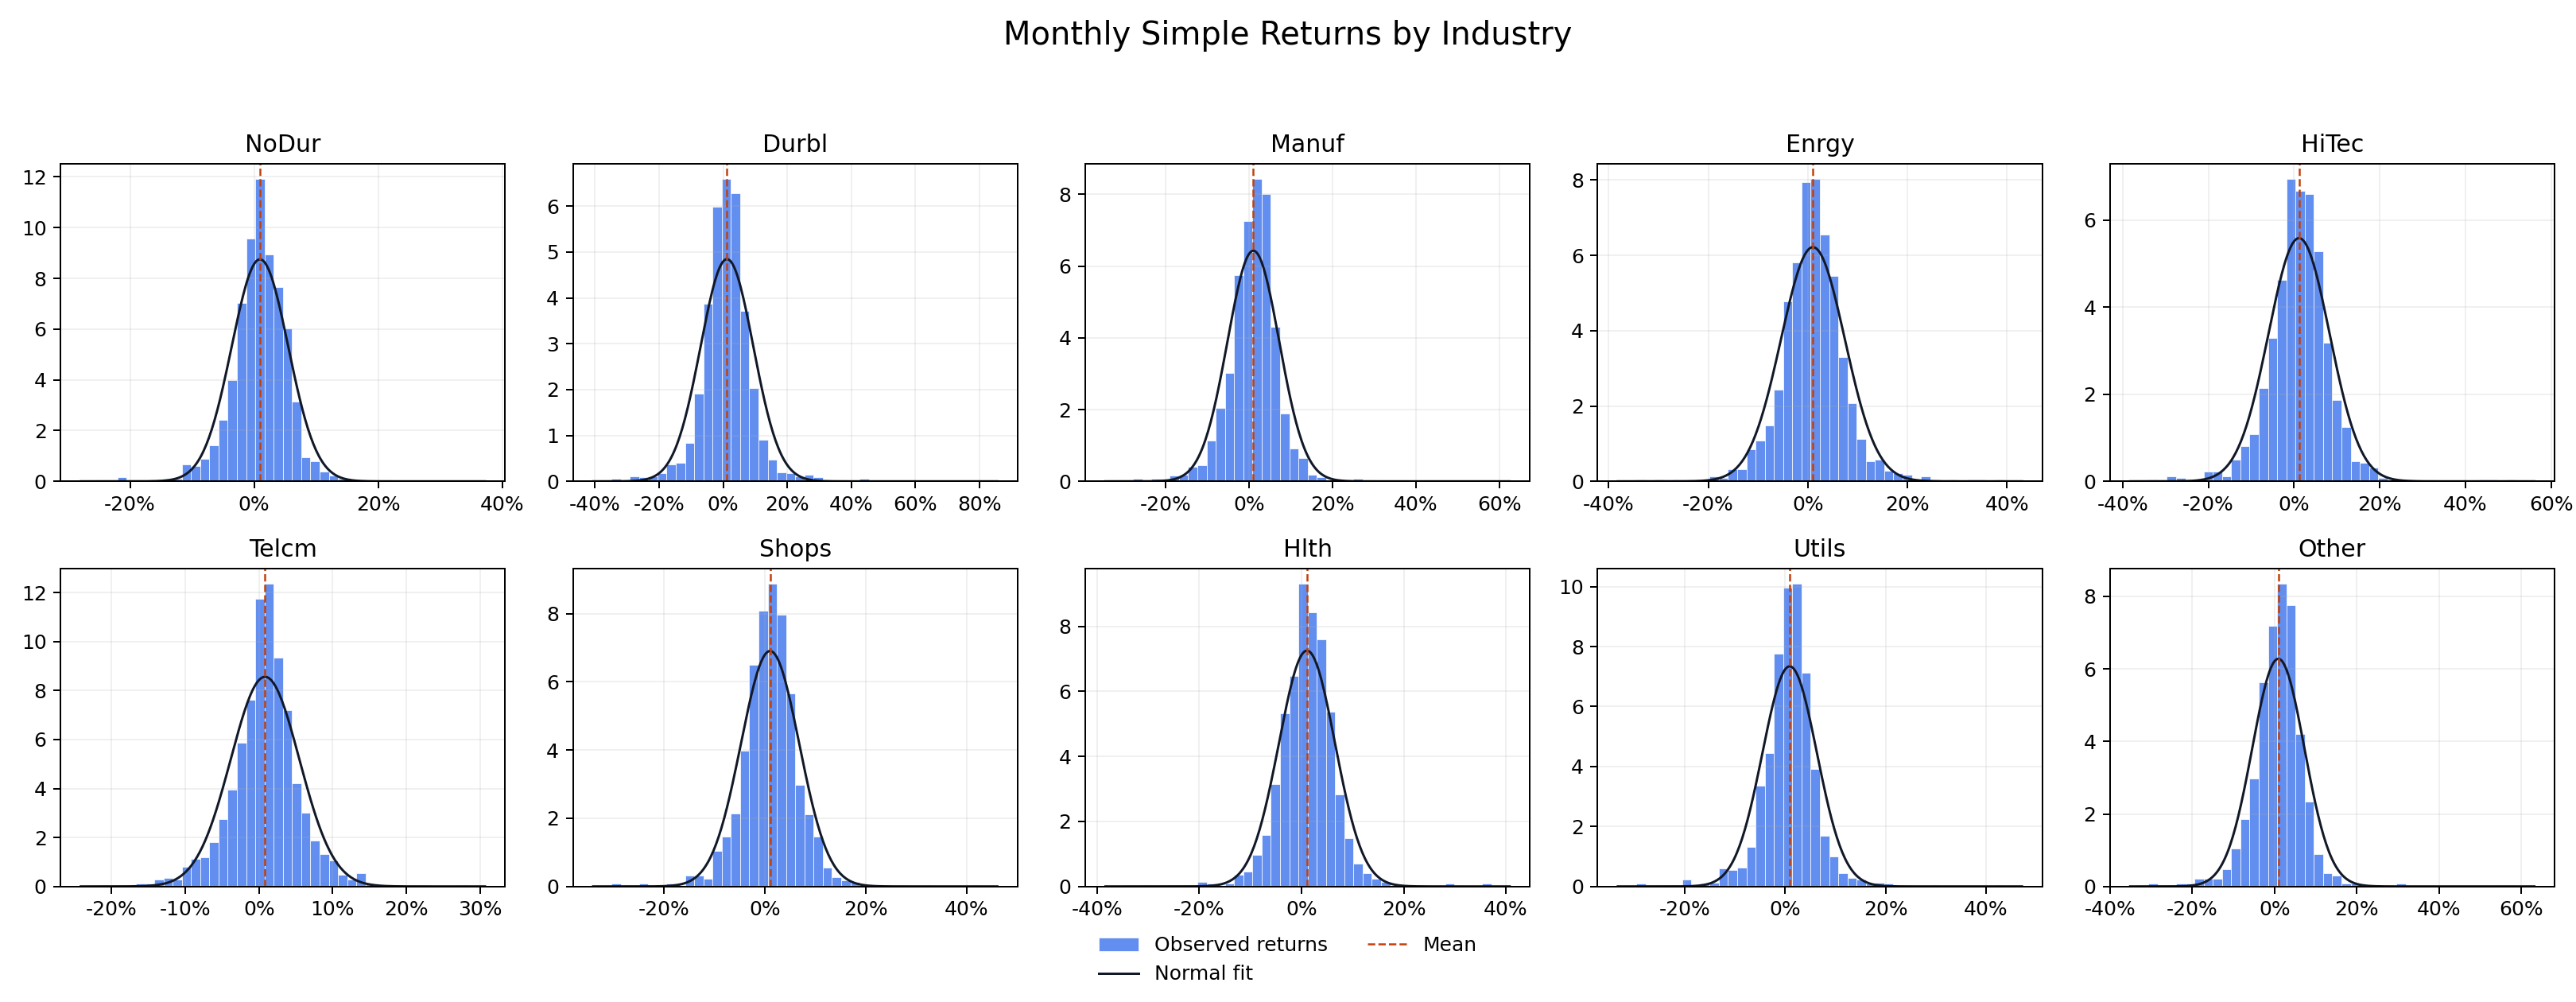

In [9]:
display(Image(filename=str(FIGURE_DIR / "industry_simple_return_histograms.png")))

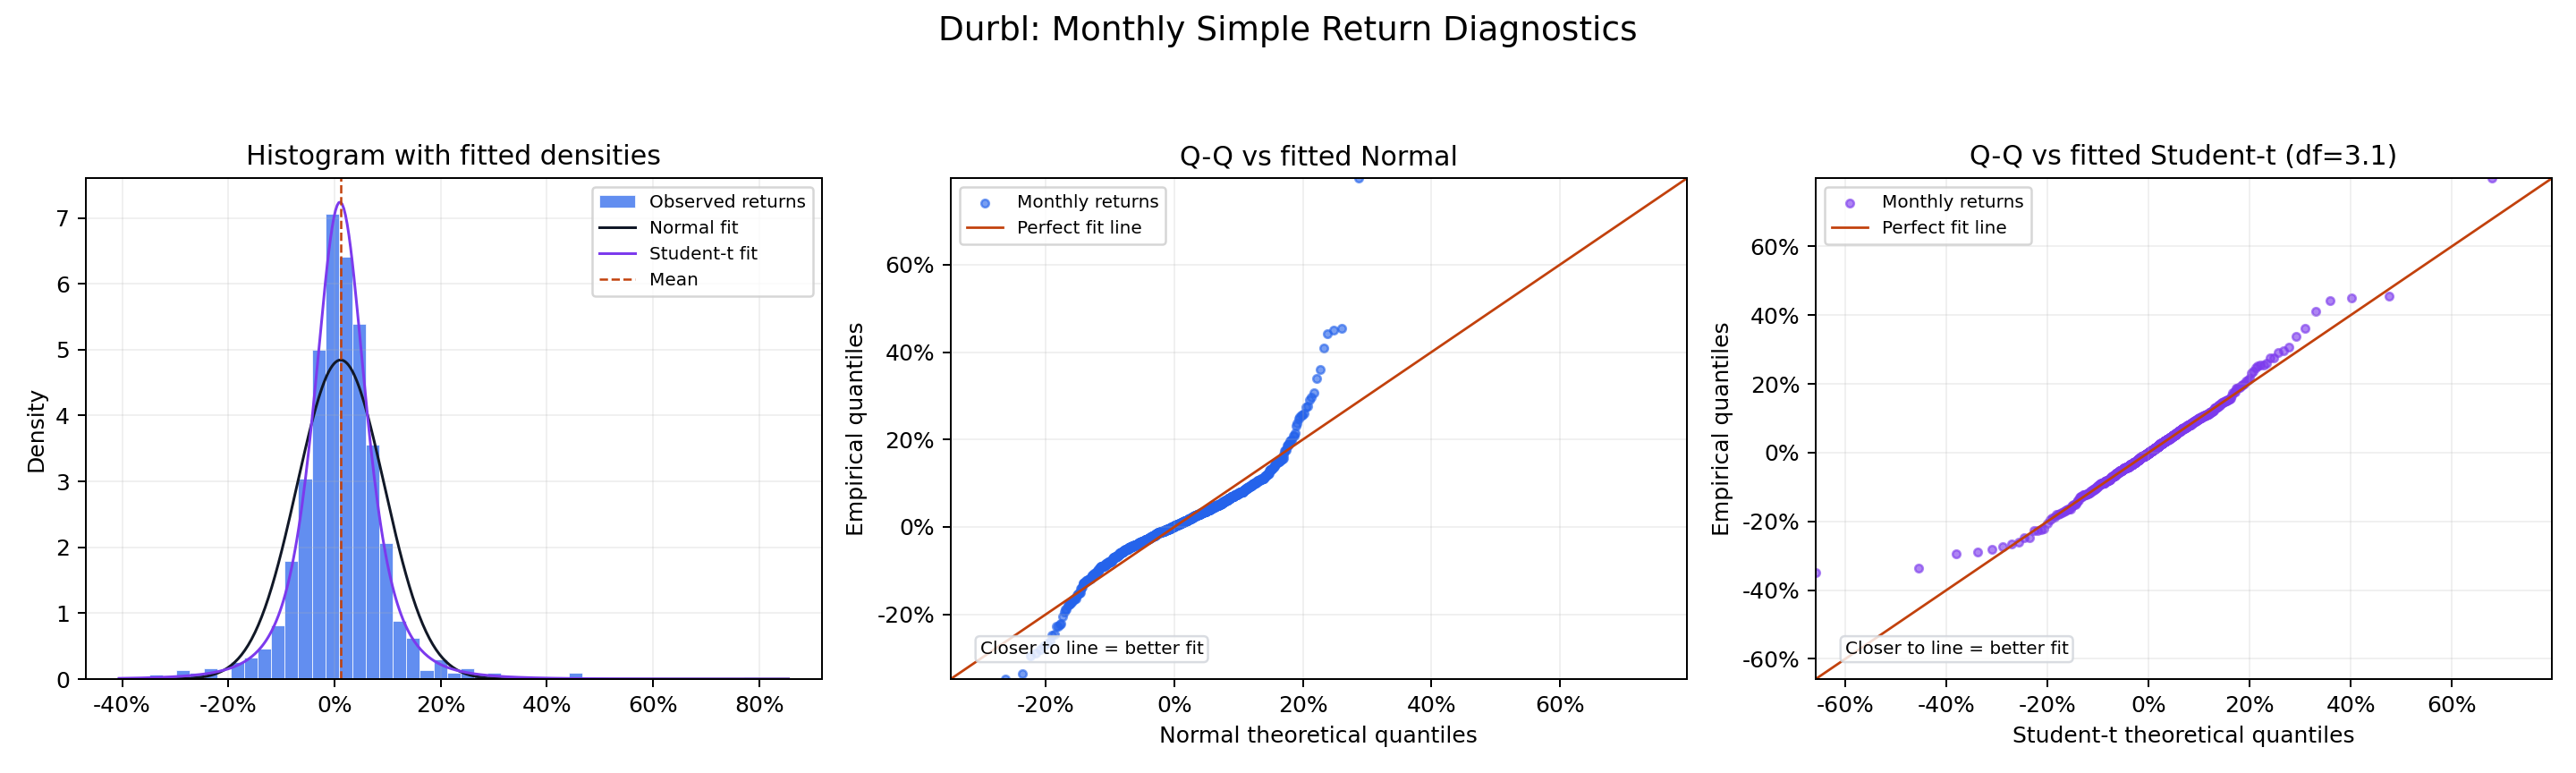

In [10]:
# Example diagnostic plot: the same files exist for all ten industries.
display(Image(filename=str(FIGURE_DIR / "durbl_distribution_diagnostics.png")))

## Bootstrap-интервалы

Bootstrap-интервалы ниже оценивают sampling uncertainty для среднего и медианы месячной доходности отрасли. Мы многократно пересэмплируем месяцы с возвращением, считаем statistic на каждом bootstrap sample и берём percentile interval 2.5%-97.5%.

Важно: это интервал для неизвестного mean/median распределения доходности, а не прогнозный интервал для следующего месячного return.

In [11]:
run_step([sys.executable, "scripts/bootstrap_industry_intervals.py"])

bootstrap_intervals = pd.read_csv(DATA_PROCESSED / "10_industry_portfolios_bootstrap_intervals.csv")
bootstrap_intervals.query("return_type == 'simple'").head(12)

$ /Library/Frameworks/Python.framework/Versions/3.11/bin/python3 scripts/bootstrap_industry_intervals.py


bootstrap intervals -> data/processed/10_industry_portfolios_bootstrap_intervals.csv (60 rows)
bootstrap interval figure -> reports/figures/industry_bootstrap_intervals_simple.png
method: percentile bootstrap, samples=10000, confidence=0.95, seed=42
Simple monthly return bootstrap summary:
highest mean estimate: HiTec 0.0116795171 [0.0075995629, 0.0156878705]
widest mean interval: Durbl width=0.0091914488
highest median estimate: Manuf 0.0136 [0.01, 0.0163]



,industry,return_type,statistic,observations,bootstrap_samples,confidence_level,estimate,ci_lower,ci_upper,ci_width,method,random_seed
0,NoDur,simple,mean,1201,10000,0.950000,0.009427,0.006894,0.012005,0.005110,percentile bootstrap,42
1,NoDur,simple,median,1201,10000,0.950000,0.010400,0.008000,0.012700,0.004700,percentile bootstrap,42
2,Durbl,simple,mean,1201,10000,0.950000,0.011656,0.007103,0.016295,0.009191,percentile bootstrap,42
3,Durbl,simple,median,1201,10000,0.950000,0.009800,0.006000,0.013700,0.007700,percentile bootstrap,42
4,Manuf,simple,mean,1201,10000,0.950000,0.010287,0.006825,0.013728,0.006904,percentile bootstrap,42
5,Manuf,simple,median,1201,10000,0.950000,0.013600,0.010000,0.016300,0.006300,percentile bootstrap,42
6,Enrgy,simple,mean,1201,10000,0.950000,0.010405,0.006732,0.014098,0.007367,percentile bootstrap,42
7,Enrgy,simple,median,1201,10000,0.950000,0.009100,0.006100,0.012500,0.006400,percentile bootstrap,42
8,HiTec,simple,mean,1201,10000,0.950000,0.011680,0.007600,0.015688,0.008088,percentile bootstrap,42
9,HiTec,simple,median,1201,10000,0.950000,0.013400,0.008700,0.017900,0.009200,percentile bootstrap,42


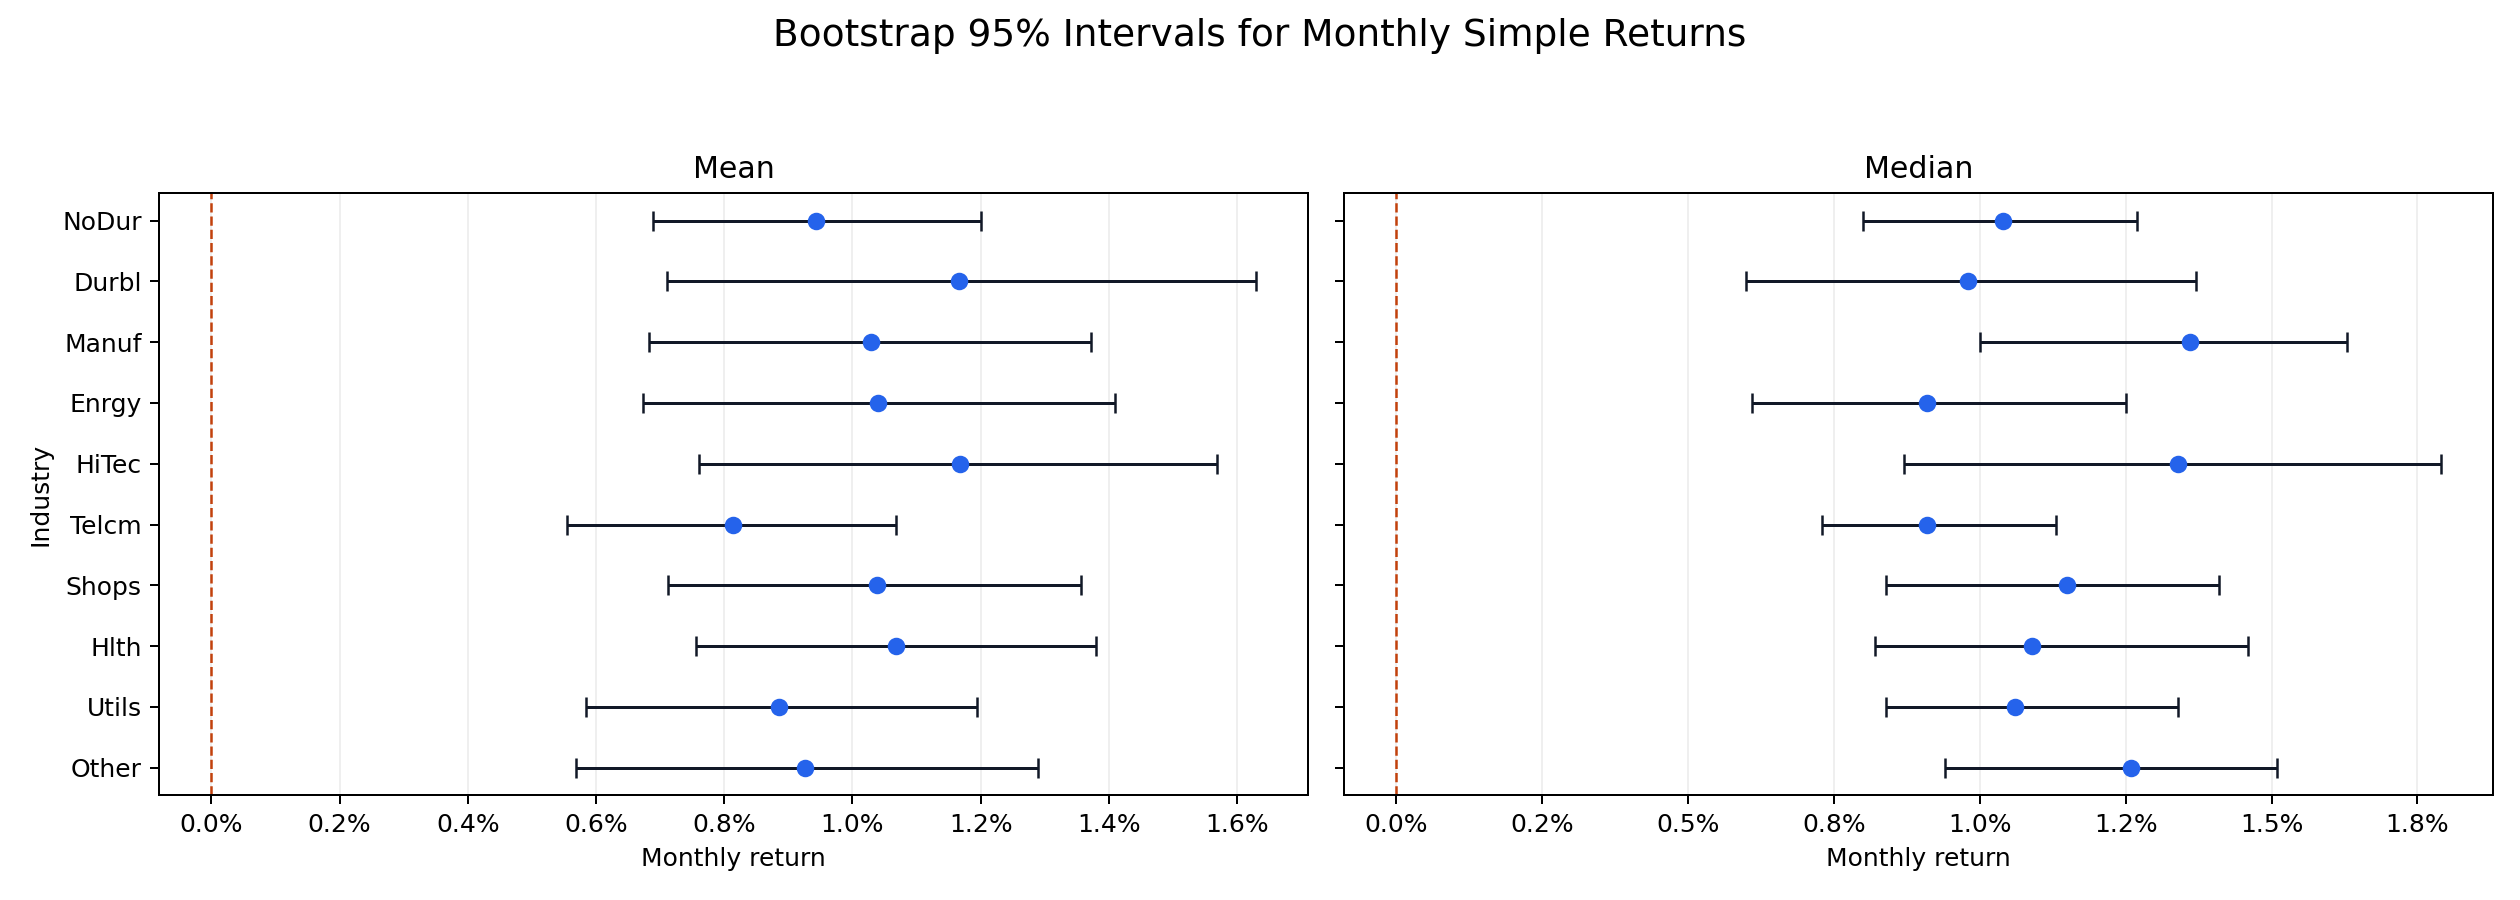

In [12]:
display(Image(filename=str(FIGURE_DIR / "industry_bootstrap_intervals_simple.png")))

## Jane Street probability tasks

Решаем четыре задачи аналитически и проверяем Монте-Карло.

1. **Maximum of 3 d6 rolls**. Для `M=max(X1,X2,X3)` используем tail-sum: `E[M]=sum_{k=1}^6 P(M>=k)=6-(0^3+...+5^3)/6^3=119/24`.
2. **One optional d6 reroll**. Второй бросок имеет EV `3.5`, поэтому reroll на `1,2,3`, keep на `4,5,6`; EV = `(3.5+3.5+3.5+4+5+6)/6=17/4`.
3. **Flips until HHH**. Состояния `E0,E1,E2` по текущей длине серии орлов: `E0=1+0.5E1+0.5E0`, `E1=1+0.5E2+0.5E0`, `E2=1+0.5E0`; решение `E0=14`.
4. **Dependence of B+R and B*R**. Если `S=B+R=2`, то обязательно `(B,R)=(1,1)` и `P=B*R=1`. Поэтому `P(P=1|S=2)=1`, но `P(P=1)=1/36`; независимости нет.

In [13]:
run_step([sys.executable, "scripts/jane_street_monte_carlo.py"])

$ /Library/Frameworks/Python.framework/Versions/3.11/bin/python3 scripts/jane_street_monte_carlo.py


1. Maximum of 3 d6 rolls
  Monte Carlo mean: 4.958509
  95% CI:           [4.956925, 4.960093]
  Analytic value:   4.958333 (119/24)
  Error:            +0.000176

2. Optional one-time d6 reroll
  Monte Carlo mean: 4.251004
  95% CI:           [4.248878, 4.253129]
  Analytic value:   4.250000 (17/4)
  Error:            +0.001004

3. Flips until HHH
  Monte Carlo mean: 13.991011
  95% CI:           [13.974519, 14.007503]
  Analytic value:   14.000000 (14)
  Error:            -0.008989

4. Dependence of B+R and B*R
  P(S = 2):                 0.027661 analytic 0.027778
  P(P = 1):                 0.027661 analytic 0.027778
  P(S = 2 and P = 1):       0.027661 analytic 0.027778
  P(P = 1 | S = 2):         1.000000 analytic 1.000000
  If independent, joint ~=  0.000765 analytic 0.000772

Since the joint probability is close to 1/36, not 1/1296, S and P are not independent.



CompletedProcess(args=['/Library/Frameworks/Python.framework/Versions/3.11/bin/python3', 'scripts/jane_street_monte_carlo.py'], returncode=0, stdout='1. Maximum of 3 d6 rolls\n  Monte Carlo mean: 4.958509\n  95% CI:           [4.956925, 4.960093]\n  Analytic value:   4.958333 (119/24)\n  Error:            +0.000176\n\n2. Optional one-time d6 reroll\n  Monte Carlo mean: 4.251004\n  95% CI:           [4.248878, 4.253129]\n  Analytic value:   4.250000 (17/4)\n  Error:            +0.001004\n\n3. Flips until HHH\n  Monte Carlo mean: 13.991011\n  95% CI:           [13.974519, 14.007503]\n  Analytic value:   14.000000 (14)\n  Error:            -0.008989\n\n4. Dependence of B+R and B*R\n  P(S = 2):                 0.027661 analytic 0.027778\n  P(P = 1):                 0.027661 analytic 0.027778\n  P(S = 2 and P = 1):       0.027661 analytic 0.027778\n  P(P = 1 | S = 2):         1.000000 analytic 1.000000\n  If independent, joint ~=  0.000765 analytic 0.000772\n\nSince the joint probability is

## Зависимые случайные величины с нулевой корреляцией

Пример: `X` равномерно принимает значения `-1, 0, 1`, а `Y=X^2`.

Они зависимы, потому что `Y` полностью определяется через `X`. Но корреляция равна нулю: `E[X]=0`, `E[XY]=E[X^3]=0`, значит `Cov(X,Y)=E[XY]-E[X]E[Y]=0`.

In [14]:
x_values = np.array([-1, 0, 1], dtype=float)
probabilities = np.array([1/3, 1/3, 1/3], dtype=float)
y_values = x_values ** 2

ex = np.sum(probabilities * x_values)
ey = np.sum(probabilities * y_values)
exy = np.sum(probabilities * x_values * y_values)
var_x = np.sum(probabilities * (x_values - ex) ** 2)
var_y = np.sum(probabilities * (y_values - ey) ** 2)
cov_xy = exy - ex * ey
corr_xy = cov_xy / np.sqrt(var_x * var_y)

pd.DataFrame(
    {
        "X": x_values,
        "Y = X^2": y_values,
        "P(X)": probabilities,
    }
), {"E[X]": ex, "E[Y]": ey, "E[XY]": exy, "Cov(X,Y)": cov_xy, "Corr(X,Y)": corr_xy}

(          X  Y = X^2     P(X)
 0 -1.000000 1.000000 0.333333
 1  0.000000 0.000000 0.333333
 2  1.000000 1.000000 0.333333,
 {'E[X]': np.float64(0.0),
  'E[Y]': np.float64(0.6666666666666666),
  'E[XY]': np.float64(0.0),
  'Cov(X,Y)': np.float64(0.0),
  'Corr(X,Y)': np.float64(0.0)})

In [15]:
rng = np.random.default_rng(20260920)
sim_x = rng.choice(x_values, size=1_000_000, p=probabilities)
sim_y = sim_x ** 2

pd.DataFrame(
    {
        "sample_corr": [np.corrcoef(sim_x, sim_y)[0, 1]],
        "P(Y=0 | X=0)": [np.mean(sim_y[sim_x == 0] == 0)],
        "P(Y=0)": [np.mean(sim_y == 0)],
    }
)

,sample_corr,P(Y=0 | X=0),P(Y=0)
0,-0.000353,1.000000,0.332924


Симуляция показывает sample correlation около `0`, но зависимость очевидна: условная вероятность `P(Y=0 | X=0)=1`, тогда как без знания `X` вероятность `P(Y=0)` около `1/3`.